In [1]:
%load_ext autoreload
%autoreload 2

In [28]:
import pandas as pd
import os
import json
import dotenv
import networkx as nx
from tqdm import tqdm

from citation_extractor import extract_echr_citations
from llm import get_completion
from prompts import get_summarizer_prompt, get_analysis_prompt
from utils import load_json, save_json, normalize, find_closest_match


dotenv.load_dotenv()

True

In [69]:
data_path = '/Users/ahmed/Desktop/msc-24/ECHR_v2/echr_processed'
files = os.listdir(data_path)

In [70]:
id_to_name = load_json('/Users/ahmed/Desktop/msc-24/ECHR_v2/id_to_name.json')
name_to_id = {v: k for k, v in id_to_name.items()}
cases_names = list(id_to_name.values())

In [71]:
# Initialize the graph
G = nx.DiGraph()

In [72]:
def get_citations_ids(law_section, case_id):
    results = extract_echr_citations(law_section)
    ids_map = {case_id: []}
    for item in results:
        cited_case_name = item['citation']['case_name']
        cited_case_name = normalize(cited_case_name)
        match_name = find_closest_match(cited_case_name, cases_names)
        cited_case_id = None
        try:
            cited_case_id = name_to_id[match_name]
        except:
            cited_case_id = None
        if cited_case_id:
            ids_map[case_id].append(cited_case_id)
    return ids_map


In [73]:
def add_case_node_to_graph(case, ids_map):
    # Add the case document as a node
    G.add_node(
        case["itemid"],
        label=case["docname"],
        type="Judgment",
        appno=case["appno"],
        importance=case["importance"],
        judgementdate=case["judgementdate"],
    )

    #print(case["itemid"], list(ids_map.keys())[0])
    assert case["itemid"] == list(ids_map.keys())[0]
    #print(list(ids_map.keys())[0])
    assert case["itemid"] == list(ids_map.keys())[0]
    # add the citations as edges
    for case_id, citations in ids_map.items():
        for cited_case_id in citations:
            G.add_edge(case_id, cited_case_id, relationship="cites")
    
    # Add article nodes
    for article in case["article"]:
        if not G.has_node(article):
            G.add_node(article, label=f"Article {article}", type="Article")
        G.add_edge(case["itemid"], article, relationship="violates")


In [74]:
for file in tqdm(files):
    if file.endswith('.json'):
        data = load_json(os.path.join(data_path, file))
        if 'law' not in data:
            continue
        law_section = data['law']
        case_id = data['itemid']
        ids_map = get_citations_ids(law_section, case_id)
        add_case_node_to_graph(data, ids_map)


  0%|          | 0/16096 [00:00<?, ?it/s]

100%|██████████| 16096/16096 [03:31<00:00, 76.26it/s] 


In [75]:
def get_cases_cited_by(graph, case_id):
    """
    Get all cases cited by a specific case.
    """
    return [target for source, target, attrs in graph.edges(data=True) if source == case_id and attrs.get("relationship") == "cites"]

In [76]:
def get_cases_citing(graph, case_id):
    """
    Get all cases that cite a specific case.
    """
    return [source for source, target, attrs in graph.edges(data=True) if target == case_id and attrs.get("relationship") == "cites"]

In [77]:
get_cases_cited_by(G, '001-220960')

['001-122664',
 '001-150778',
 '001-85019',
 '001-127697',
 '001-126025',
 '001-57927',
 '001-89161',
 '001-97425',
 '001-103663',
 '001-76766',
 '001-173776',
 '001-163671']

In [78]:
get_cases_citing(G, '001-220960')

[]

In [79]:
def get_subgraph_for_node(graph, node_id, depth=1):
    """
    Extract a subgraph for a specific node and its neighbors up to a certain depth.
    """
    if not graph.has_node(node_id):
        raise ValueError(f"Node {node_id} does not exist in the graph.")
    
    # Get all nodes within the specified depth
    nodes_in_subgraph = nx.single_source_shortest_path_length(graph, node_id, cutoff=depth).keys()
    
    # Create the subgraph
    subgraph = graph.subgraph(nodes_in_subgraph).copy()
    
    return subgraph


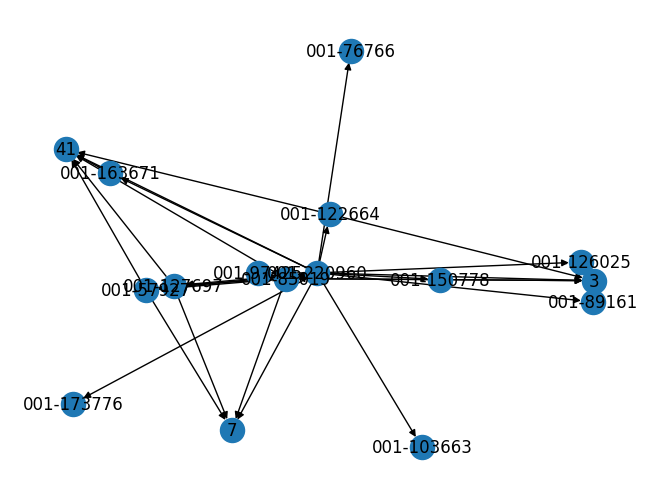

In [84]:
subgraph = get_subgraph_for_node(G, '001-220960', depth=1)

import matplotlib.pyplot as plt
nx.draw(subgraph, with_labels=True)
plt.show()

In [135]:
import matplotlib.pyplot as plt
import networkx as nx
import matplotlib.cm as cm
import matplotlib.colors as mcolors

def visualize_subgraph_with_importance(graph, node_id, depth=1):
    """
    Visualize a subgraph with case IDs as labels, highlighting the main queried case,
    and representing importance (1=most important, 4=least important) via node color intensity.

    Args:
        graph (networkx.Graph): The graph containing the nodes and edges.
        node_id (str): The ID of the main queried node to highlight.
        depth (int): The depth of neighbors to include in the subgraph (default: 1).
    """
    # Get the subgraph
    subgraph = get_subgraph_for_node(graph, node_id, depth)

    # Prepare attributes for visualization
    node_colors = []
    node_sizes = []
    labels = {}

    # Define a color map for importance
    importance_values = [
        int(attrs.get("importance", 4)) for node, attrs in subgraph.nodes(data=True) if attrs.get("type") == "Judgment"
    ]
    max_importance = max(importance_values) if importance_values else 4
    min_importance = min(importance_values) if importance_values else 1
    color_map = cm.get_cmap("Blues", 256)  # Blue gradient

    for node, attrs in subgraph.nodes(data=True):
        if node == node_id:
            # Highlight the main queried case
            node_colors.append("red")  # Main case color
            node_sizes.append(800)  # Larger size for emphasis
            labels[node] = node  # Use case ID as the label
        elif attrs.get("type") == "Judgment":
            # Map importance to a color (reverse scale: 1=dark, 4=light)
            importance = int(attrs.get("importance", 4))
            normalized_importance = (max_importance - importance) / (max_importance - min_importance) if max_importance != min_importance else 0
            node_colors.append(mcolors.to_hex(color_map(normalized_importance)))  # Gradient color
            node_sizes.append(1000 + (4 - importance) * 200)  # Larger size for higher importance
            labels[node] = node  # Use case ID as the label
        elif attrs.get("type") == "Article":
            node_colors.append("lightgreen")  # Fixed color for articles
            node_sizes.append(600)
            labels[node] = node  # Use article ID as the label
        else:
            node_colors.append("lightgray")  # Default color for other nodes
            node_sizes.append(300)
            labels[node] = node  # Default to node ID

    # Draw the graph
    plt.figure(figsize=(12, 10))
    pos = nx.kamada_kawai_layout(subgraph)  # Kamada-Kawai layout for small graphs

    # Draw nodes, edges, and labels
    nx.draw(
        subgraph,
        pos,
        with_labels=False,  # We'll add labels separately
        node_color=node_colors,
        node_size=node_sizes,
        edge_color="gray",
        alpha=0.8
    )

    # Draw labels
    nx.draw_networkx_labels(
        subgraph,
        pos,
        labels=labels,
        font_size=10,
        font_color="black",
        font_weight="bold",
        bbox=dict(facecolor="white", edgecolor="black", boxstyle="round,pad=0.3"),
    )

    # Add a legend
    legend_labels = {
        "Main Case (Queried)": "red",
        "Cases (Judgment)": color_map(0.8),  # Representative mid-tone from gradient
        "Articles": "lightgreen"
    }
    for label, color in legend_labels.items():
        plt.scatter([], [], c=color, label=label, s=300, edgecolor="black")
    plt.legend(scatterpoints=1, frameon=True, labelspacing=1, title="Node Type")

    plt.title(f"Subgraph Visualization for Node: {node_id} (Importance Highlighted)", fontsize=14)
    plt.axis("off")  # Hide axes
    plt.show()


/var/folders/dl/d24xg2c11gx7r5rs5b6kd_780000gn/T/ipykernel_35830/892684207.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = cm.get_cmap("Blues", 256)  # Blue gradient
/var/folders/dl/d24xg2c11gx7r5rs5b6kd_780000gn/T/ipykernel_35830/892684207.py:87: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter([], [], c=color, label=label, s=300, edgecolor="black")


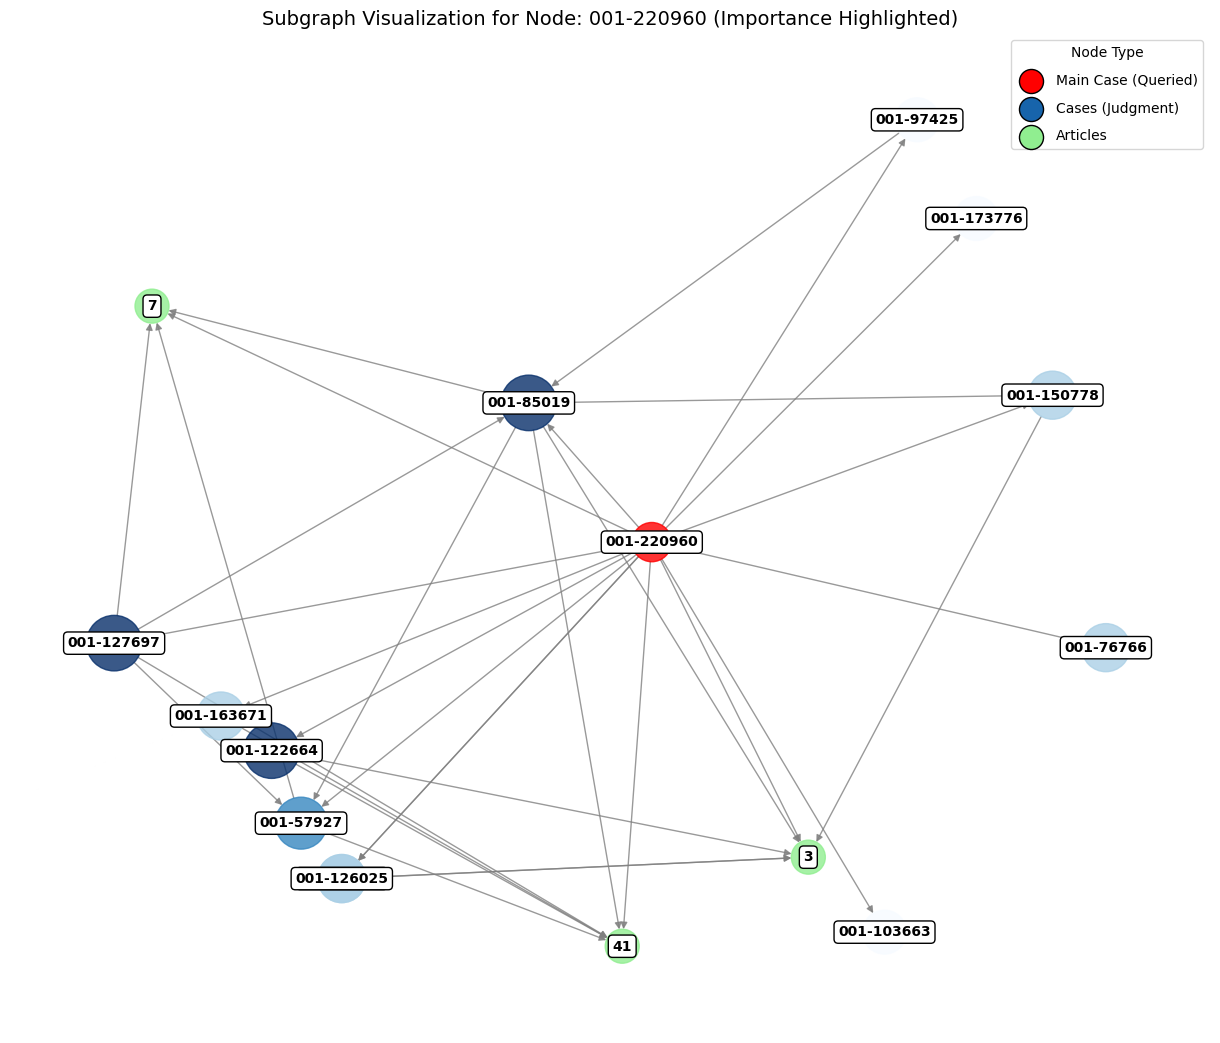

In [136]:
visualize_subgraph_with_importance(G, '001-220960', depth=1)

In [149]:
def visualize_subgraph_with_discrete_importance(graph, node_id, depth=1):
    """
    Visualize a subgraph with case IDs as labels, highlighting the main queried case,
    and representing importance (1=most important, 4=least important) using distinct colors.
    Includes a legend for importance levels.

    Args:
        graph (networkx.Graph): The graph containing the nodes and edges.
        node_id (str): The ID of the main queried node to highlight.
        depth (int): The depth of neighbors to include in the subgraph (default: 1).
    """
    # Get the subgraph
    subgraph = get_subgraph_for_node(graph, node_id, depth)

    # Define distinct colors for importance levels
    importance_colors = {
        1: "darkblue",
        2: "blue",
        3: "lightblue",
        4: "skyblue"
    }

    # Prepare attributes for visualization
    node_colors = []
    node_sizes = []
    labels = {}

    for node, attrs in subgraph.nodes(data=True):
        if node == node_id:
            # Highlight the main queried case
            node_colors.append("red")  # Main case color
            node_sizes.append(800)  # Larger size for emphasis
            labels[node] = node  # Use case ID as the label
        elif attrs.get("type") == "Judgment":
            # Assign color based on importance
            importance = int(attrs.get("importance", 4))
            node_colors.append(importance_colors.get(importance, "gray"))  # Default to gray if importance is missing
            node_sizes.append(1000 + (4 - importance) * 200)  # Larger size for higher importance
            labels[node] = node  # Use case ID as the label
        elif attrs.get("type") == "Article":
            node_colors.append("lightgreen")  # Fixed color for articles
            node_sizes.append(600)
            labels[node] = node  # Use article ID as the label
        else:
            node_colors.append("lightgray")  # Default color for other nodes
            node_sizes.append(300)
            labels[node] = node  # Default to node ID

    # Draw the graph
    plt.figure(figsize=(14, 12))
    pos = nx.kamada_kawai_layout(subgraph)  # Kamada-Kawai layout for small graphs

    # Draw nodes, edges, and labels
    nx.draw(
        subgraph,
        pos,
        with_labels=False,  # We'll add labels separately
        node_color=node_colors,
        node_size=node_sizes,
        edge_color="gray",
        alpha=0.8
    )

    # Draw labels
    nx.draw_networkx_labels(
        subgraph,
        pos,
        labels=labels,
        font_size=10,
        font_color="black",
        font_weight="bold",
        bbox=dict(facecolor="white", edgecolor="black", boxstyle="round,pad=0.3"),
    )

    # Add a legend
    legend_labels = {
        "Main Case (Queried)": "red",
        "Articles": "lightgreen",
        "Importance 1 (Most Important)": "darkblue",
        "Importance 2": "blue",
        "Importance 3": "lightblue",
        "Importance 4 (Least Important)": "skyblue"
    }
    for label, color in legend_labels.items():
        plt.scatter([], [], c=color, label=label, s=300, edgecolor="black")
    plt.legend(scatterpoints=1, frameon=True, labelspacing=1, title="Node Type / Importance")

    plt.title(f"Subgraph Visualization for Node: {node_id} (Importance Highlighted)", fontsize=14)
    plt.axis("off")  # Hide axes
    plt.show()


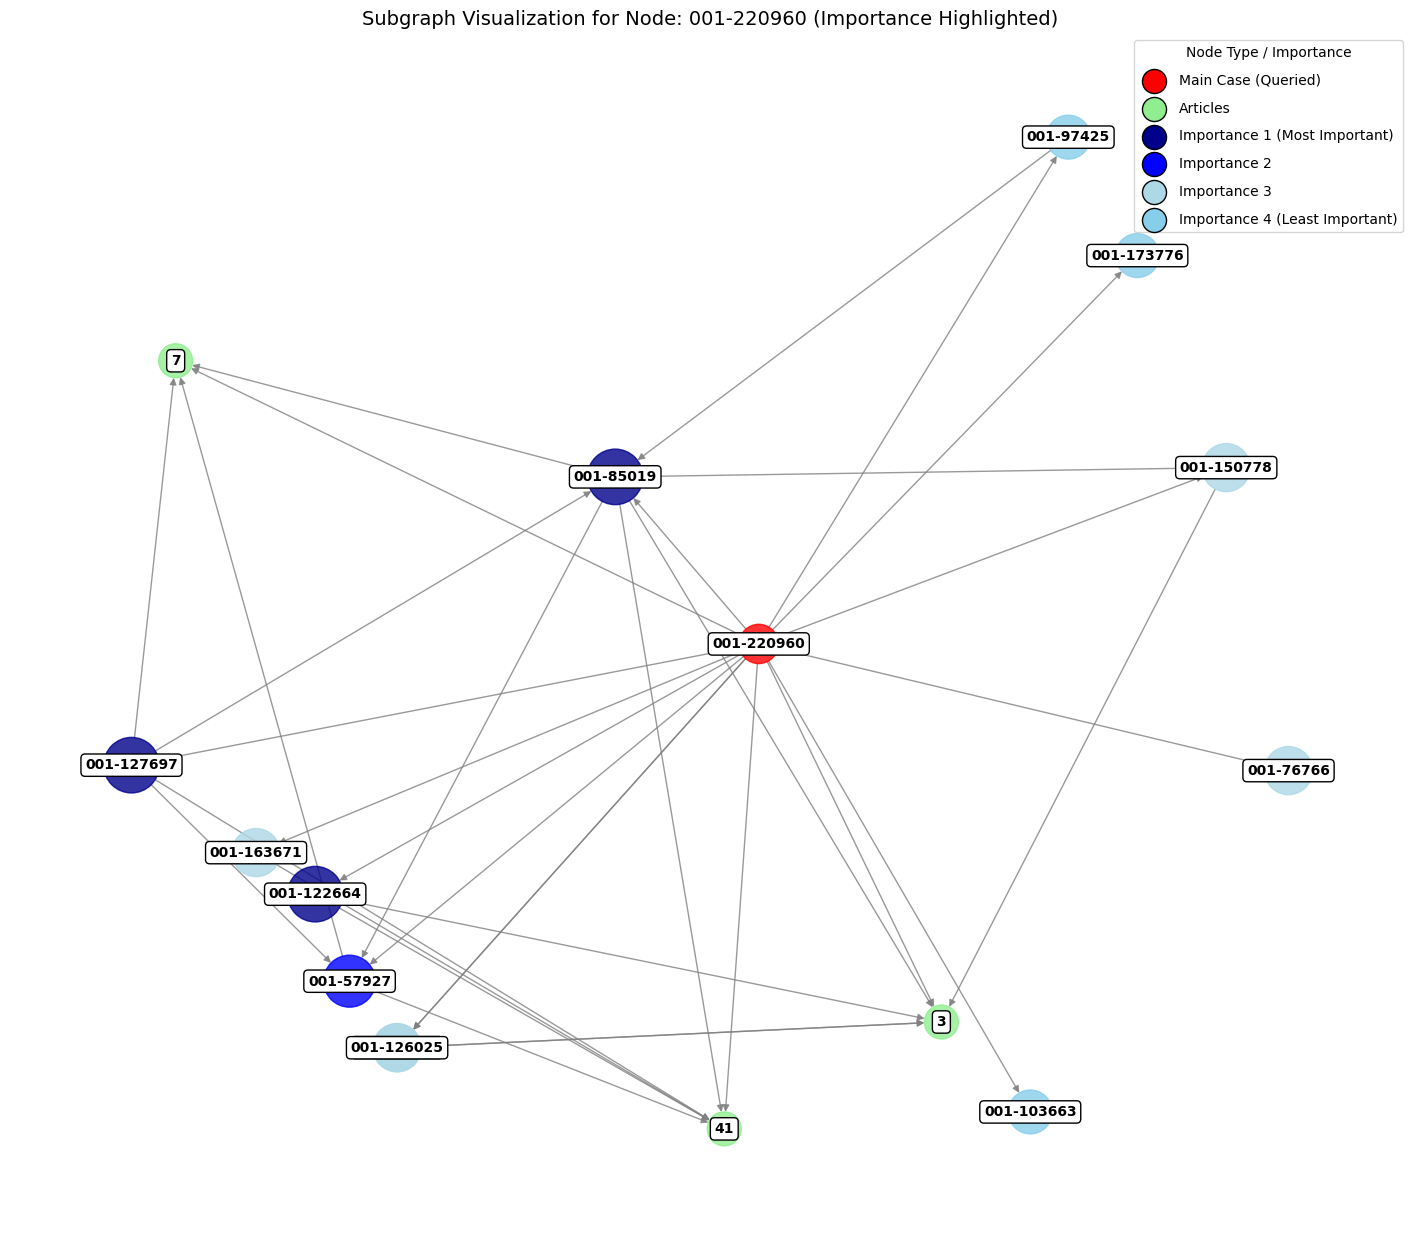

In [150]:
visualize_subgraph_with_discrete_importance(G, "001-220960", depth=1)
